In [1]:
from scipy.stats import pearsonr
import pandas as pd

In [11]:
county =""

df = pd.read_csv(f"../bivariate_map/{county}_csv/{county}_bivariate_data.csv")

subset = df[["final_health_composite", "final_income_mobility_composite"]].dropna()

l1 = subset["final_health_composite"]
l2 = subset["final_income_mobility_composite"]

corr, _ =pearsonr(l1,l2)

print('Pearsons correlation: %.3f' % corr)

Pearsons correlation: -0.296


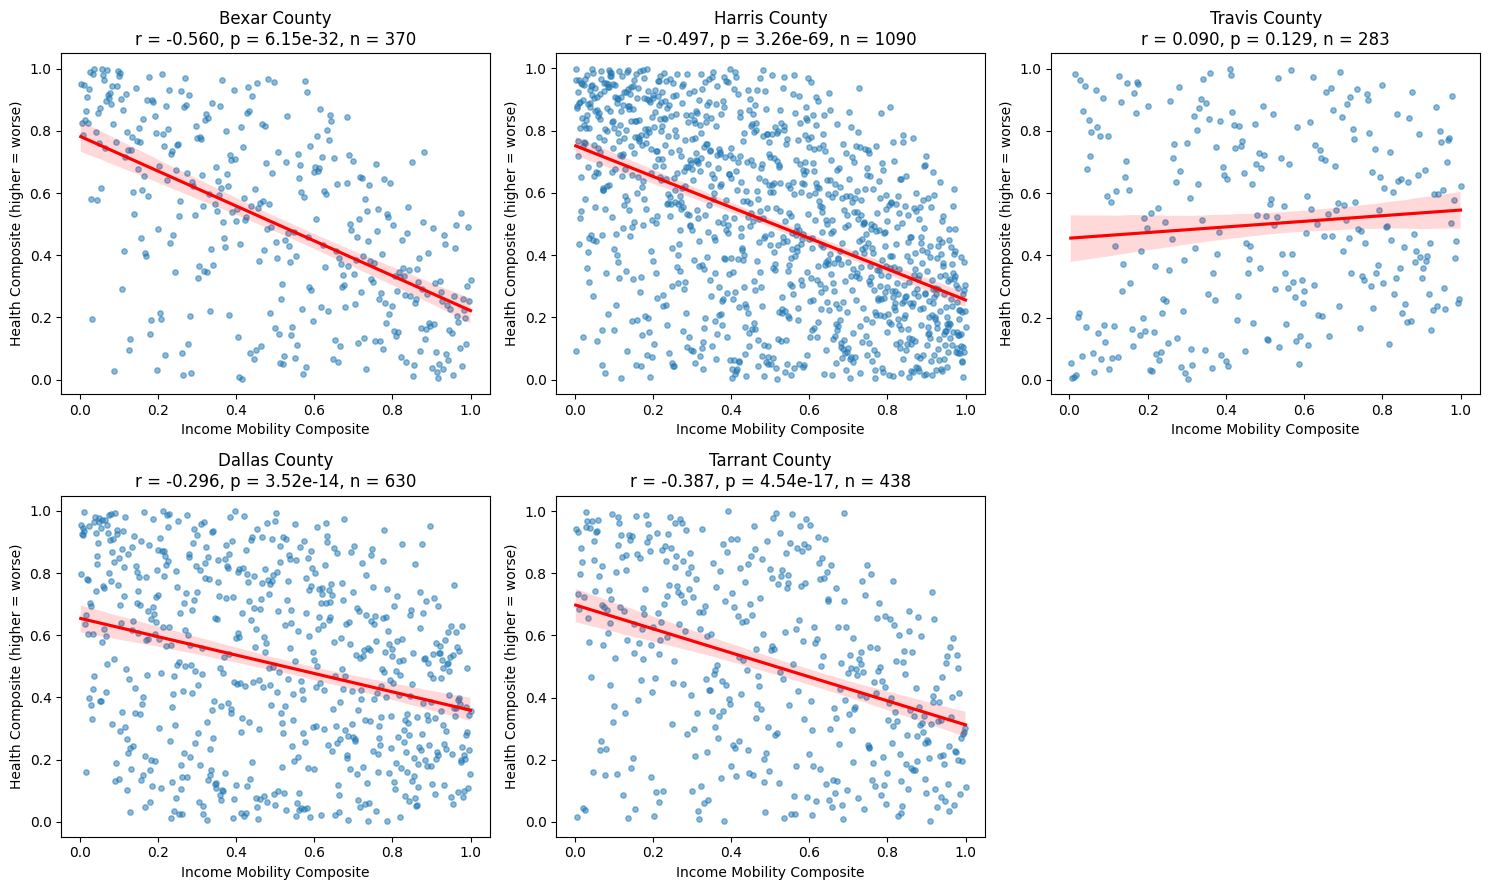

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

counties = ["bexar", "harris", "travis", "dallas", "tarrant"]  # replace with your 5

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, county in enumerate(counties):
    df = pd.read_csv(f"../bivariate_map/{county}_csv/{county}_bivariate_data.csv")
    subset = df[["final_health_composite", "final_income_mobility_composite"]].dropna()

    y = subset["final_health_composite"]
    x = subset["final_income_mobility_composite"]
    r, p = pearsonr(x, y)

    sns.regplot(x=x, y=y, ax=axes[i], scatter_kws={"alpha": 0.5, "s": 15}, line_kws={"color": "red"})
    axes[i].set_title(f"{county.title()} County\nr = {r:.3f}, p = {p:.3g}, n = {len(subset)}")
    axes[i].set_xlabel("Income Mobility Composite")
    axes[i].set_ylabel("Health Composite (higher = worse)")

# hide any unused subplot slots
for j in range(len(counties), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("correlation_scatterplots.png", dpi=150)
plt.show()